In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("dirty_machine_data.csv")
data.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2568,L49747,L,299.4,309.1,1766.0,NaN,158.0,0.0,0.0,0.0,0.0,NaN,0.0
1,2176,M17035,M,299.5,NaN,1590.0,35.9,22.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7783,M22642,M,300.4,311.6,1518.0,36.4,53.0,0.0,0.0,0.0,0.0,0.0,NaN
3,8970,L56149,L,297.0,307.8,1396.0,50.0,96.0,0.0,0.0,0.0,NaN,0.0,0.0
4,7506,L54685,L,300.5,311.9,1546.0,39.4,203.0,0.0,0.0,0.0,0.0,0.0,0.0
5,5856,M20715,M,301.2,310.9,1424.0,45.2,68.0,0.0,0.0,0.0,0.0,NaN,0.0
6,7863,M22722,M,300.5,312.0,1382.0,54.1,27.0,0.0,0.0,0.0,0.0,0.0,0.0
7,8044,L55223,L,300.7,311.9,1486.0,35.8,32.0,0.0,0.0,0.0,0.0,0.0,0.0
8,8007,L55186,L,300.9,312.1,1462.0,46.0,166.0,NaN,0.0,NaN,0.0,0.0,0.0
9,9649,L56828,L,299.1,310.1,1416.0,41.2,185.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10500 non-null  int64  
 1   Product ID               10500 non-null  object 
 2   Type                     10500 non-null  object 
 3   Air temperature [K]      10185 non-null  float64
 4   Process temperature [K]  10185 non-null  float64
 5   Rotational speed [rpm]   10185 non-null  float64
 6   Torque [Nm]              10185 non-null  float64
 7   Tool wear [min]          10185 non-null  float64
 8   Machine failure          10185 non-null  float64
 9   TWF                      10185 non-null  float64
 10  HDF                      10185 non-null  float64
 11  PWF                      10185 non-null  float64
 12  OSF                      10185 non-null  float64
 13  RNF                      10185 non-null  float64
dtypes: float64(11), int64(

In [5]:
data.shape

(10500, 14)

In [6]:
data.isna().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],315
Process temperature [K],315
Rotational speed [rpm],315
Torque [Nm],315
Tool wear [min],315
Machine failure,315
TWF,315


In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
cols_with_na = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]", "TWF", "HDF", "PWF", "OSF", "RNF"]
imp = IterativeImputer()
data[cols_with_na] = imp.fit_transform(data[cols_with_na])

In [8]:
print("sum of duplicated data = ", data.duplicated().sum())

sum of duplicated data =  229


In [9]:
data.drop_duplicates(inplace = True)
print("sum of duplicated data = ", data.duplicated().sum())

sum of duplicated data =  0


In [10]:
data.drop(["UDI", "Product ID"], axis = 1, inplace = True)

In [11]:
data = data[data["Machine failure"] <= 1]

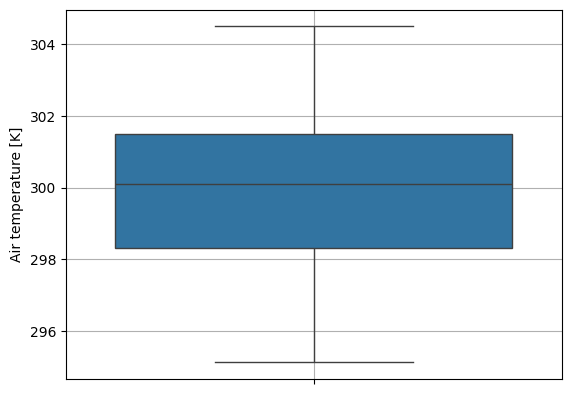

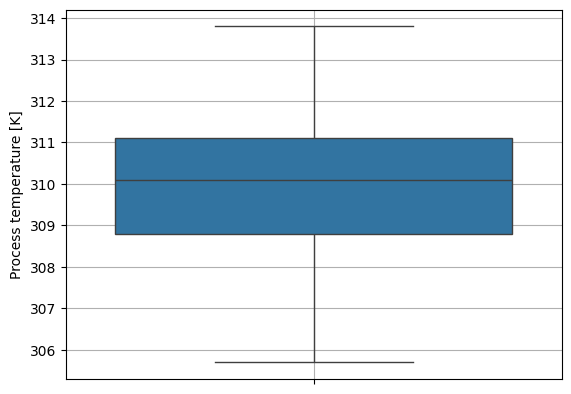

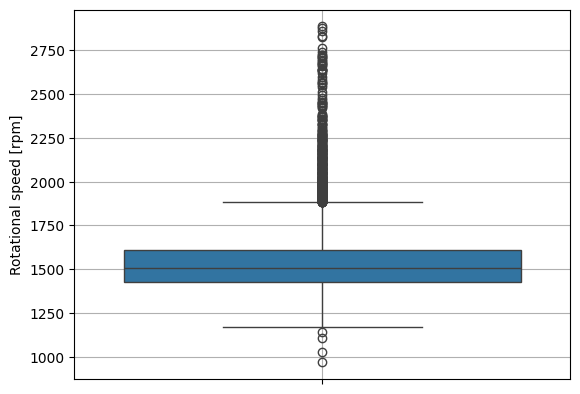

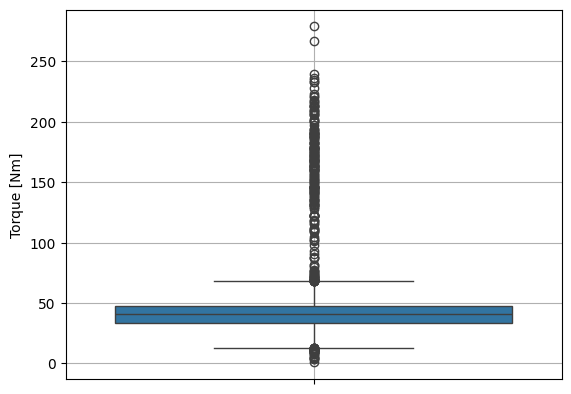

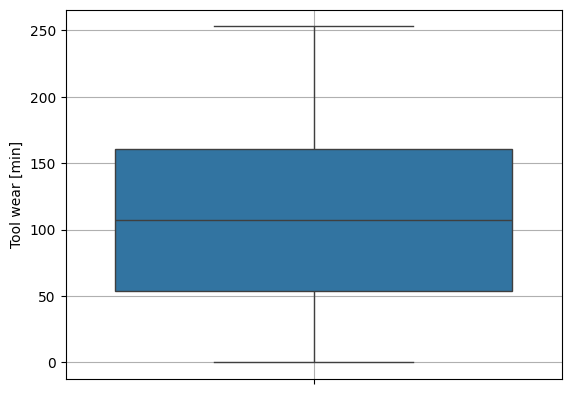

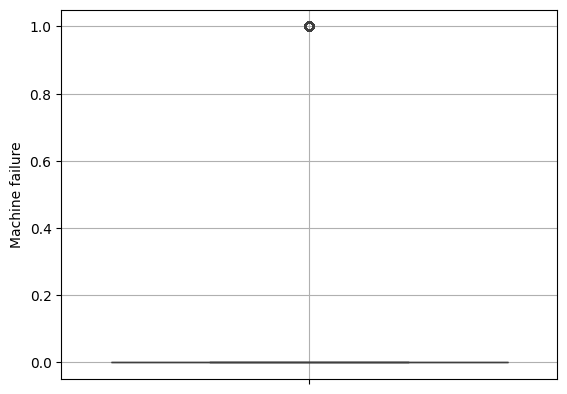

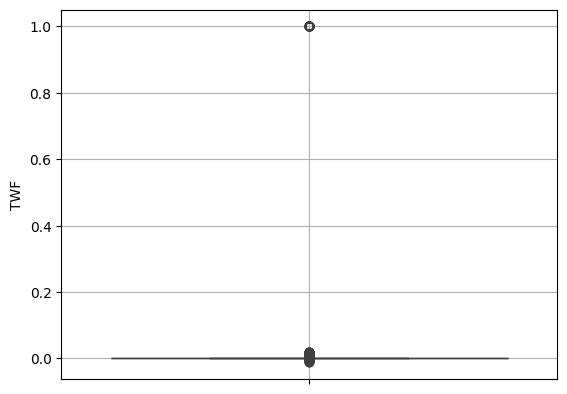

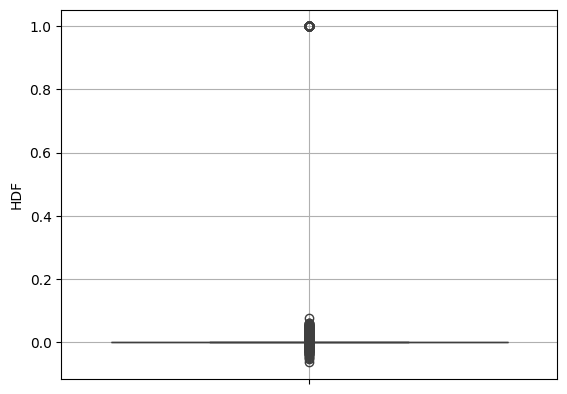

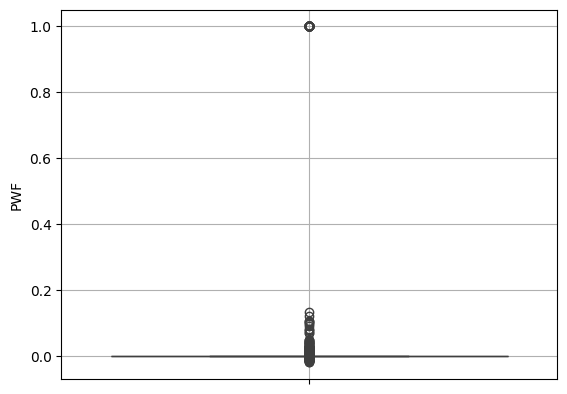

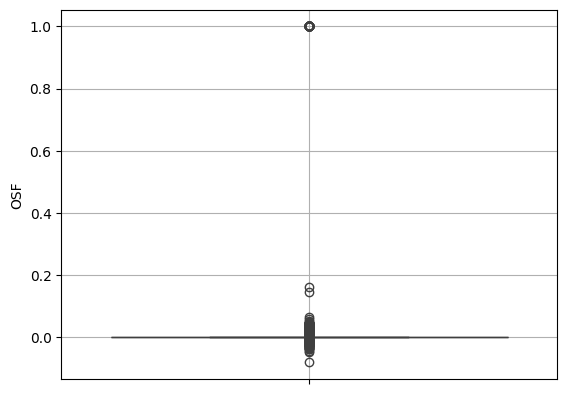

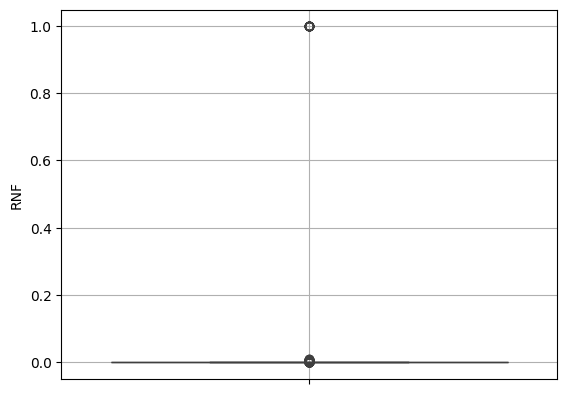

In [12]:
numerical_col = data.select_dtypes(include = ["int64", "float64"])
for col in numerical_col:
    sns.boxplot(data[col])
    plt.grid(True)
    plt.show()

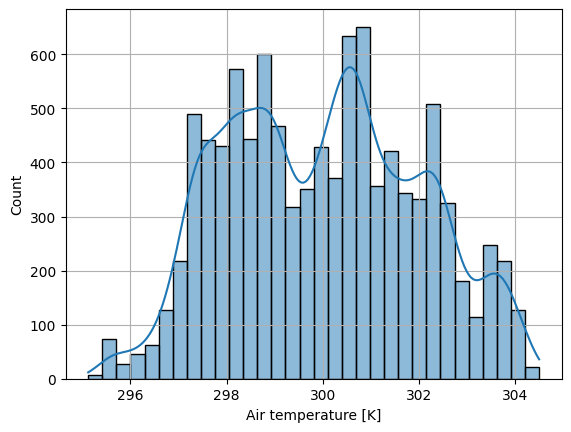

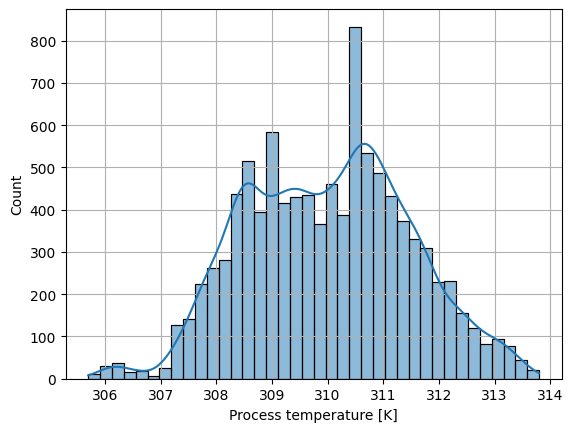

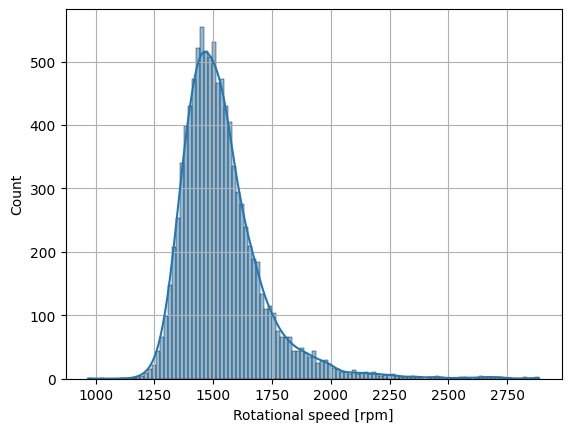

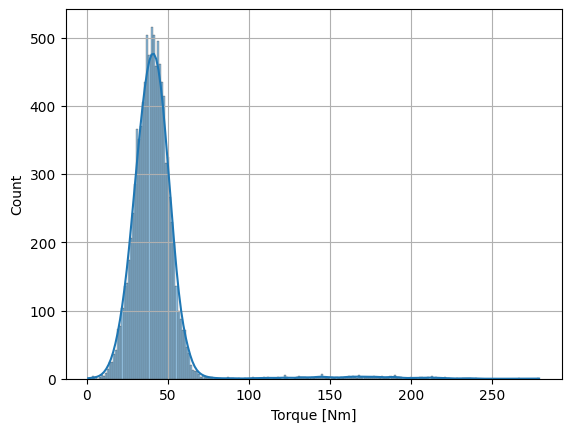

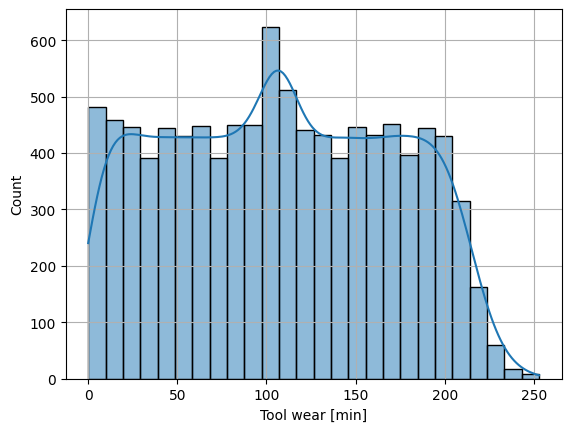

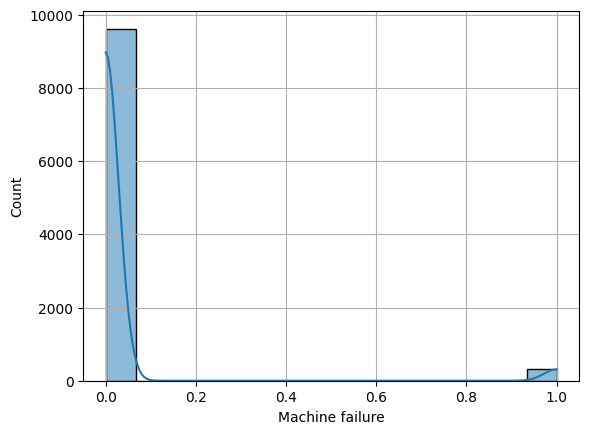

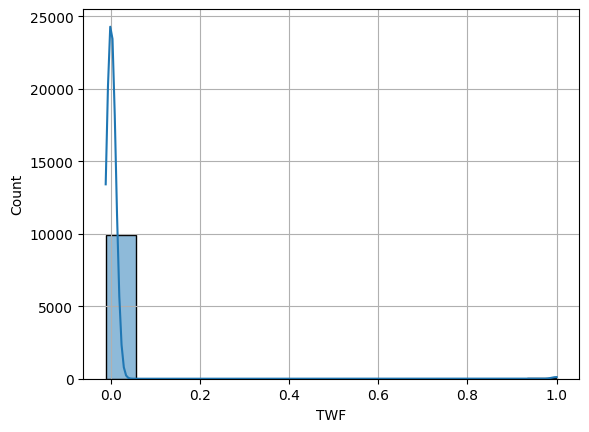

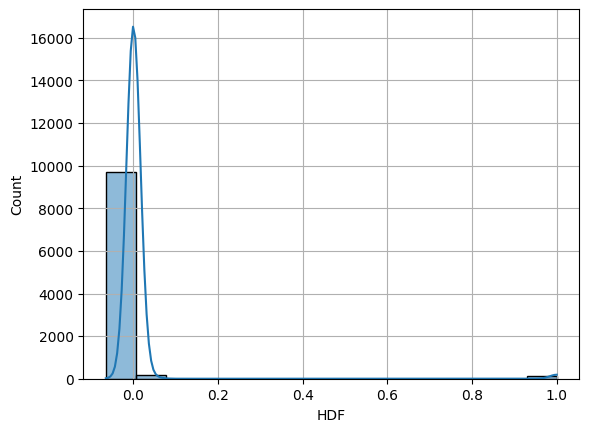

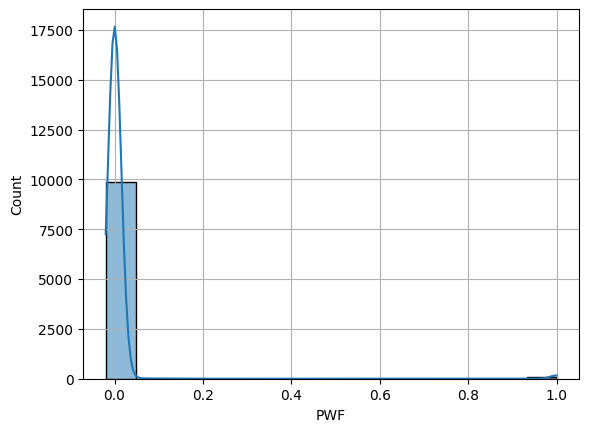

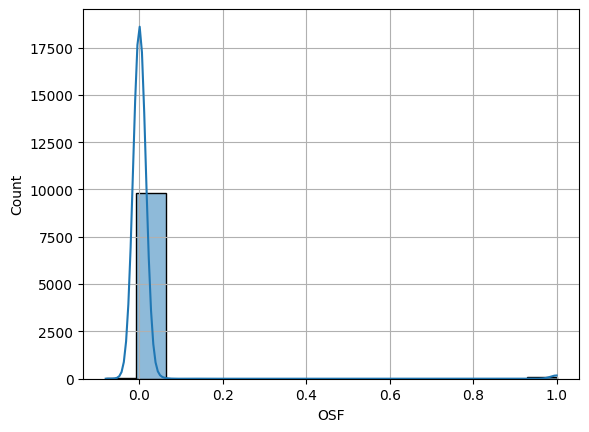

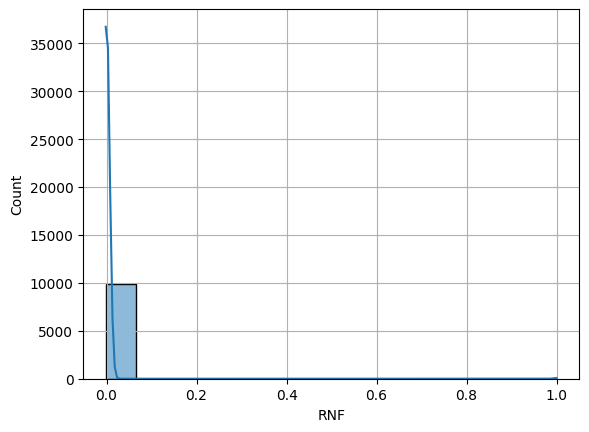

In [13]:
for col in numerical_col:
    sns.histplot(data[col], kde = True)
    plt.grid(True)
    plt.show()

In [14]:
data["HDF"] = data["HDF"].clip(lower = 0)
data["OSF"] = data["OSF"].clip(lower = 0)
data["TWF"] = data["TWF"].clip(lower = 0)
data["PWF"] = data["PWF"].clip(lower = 0)

In [15]:
cols = ["HDF", "OSF", "TWF", "Machine failure", "RNF", "PWF"]
for col in cols:
    data[col] = np.round(data[col])
data["Rotational speed [rpm]"] = np.log1p(data["Rotational speed [rpm]"])
data["Torque [Nm]"] = np.log1p(data["Torque [Nm]"])

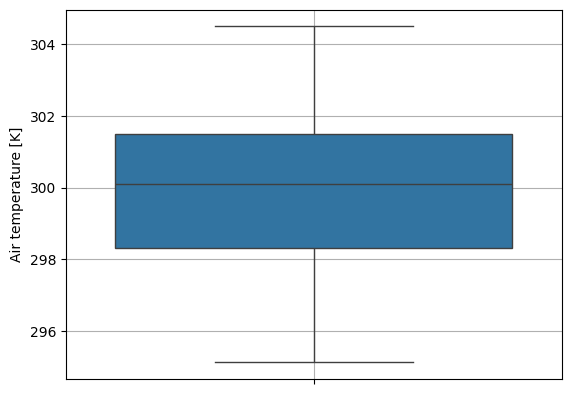

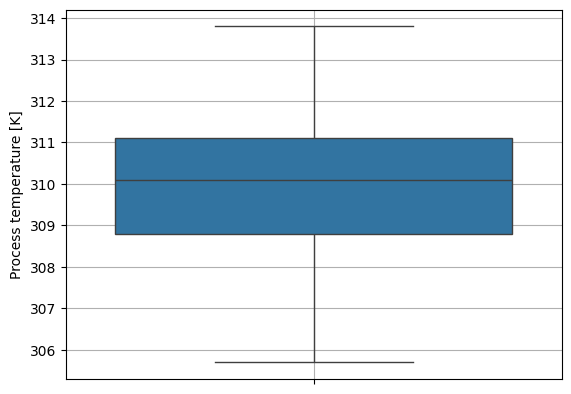

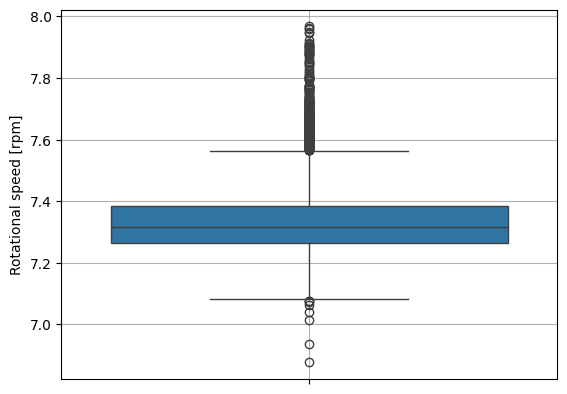

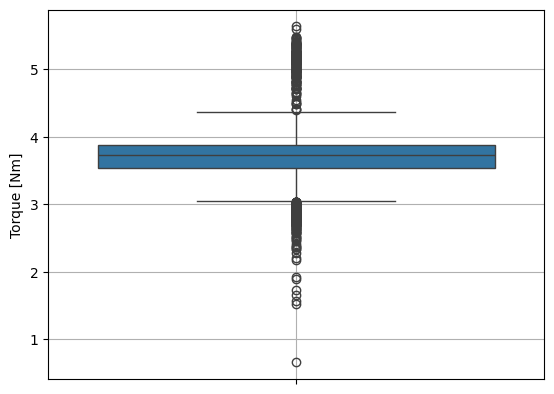

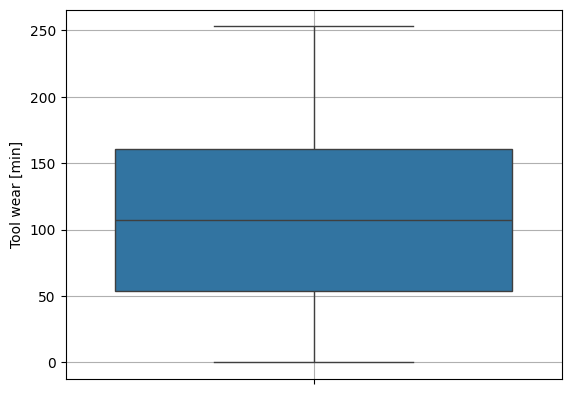

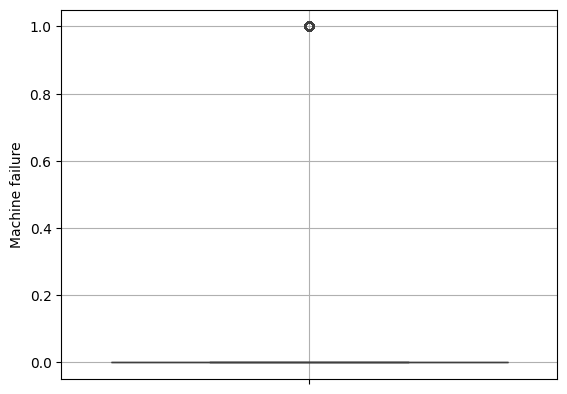

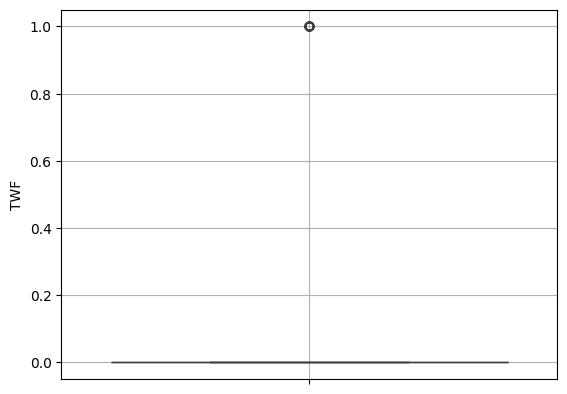

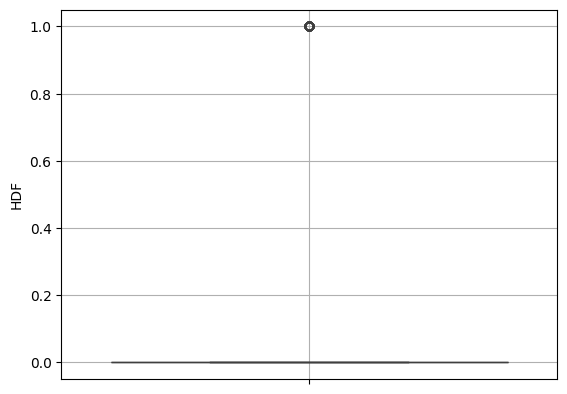

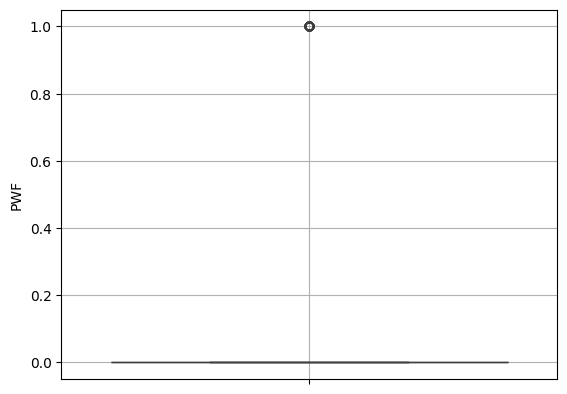

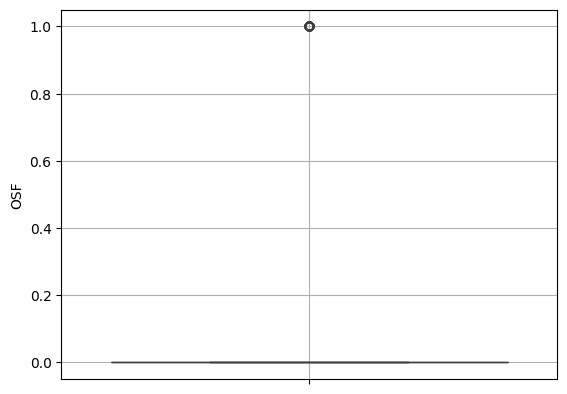

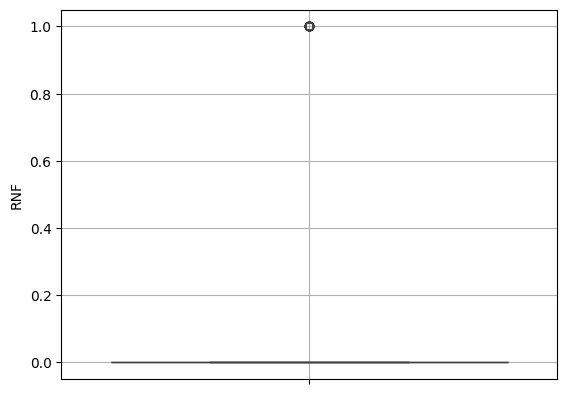

In [16]:
numerical_col = data.select_dtypes(include = ["int64", "float64"])
for col in numerical_col:
    sns.boxplot(data[col])
    plt.grid(True)
    plt.show()

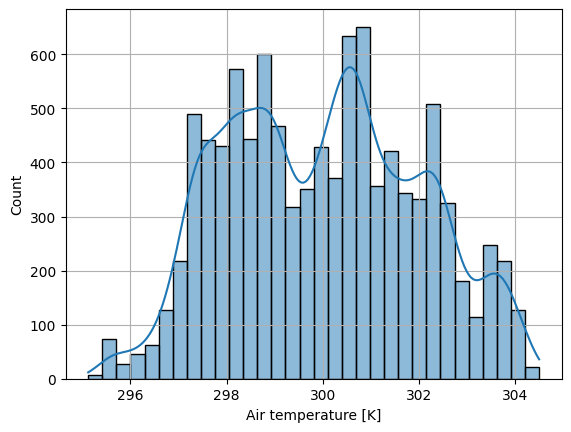

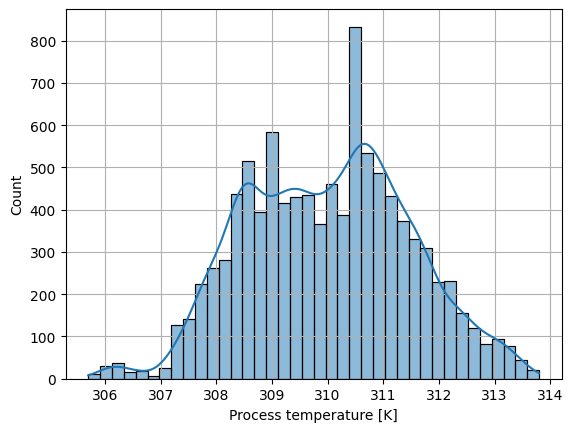

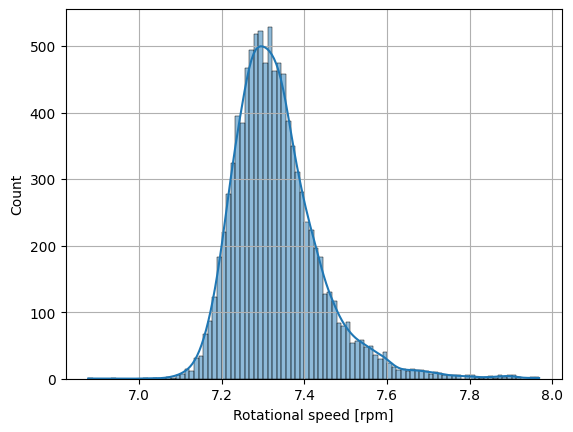

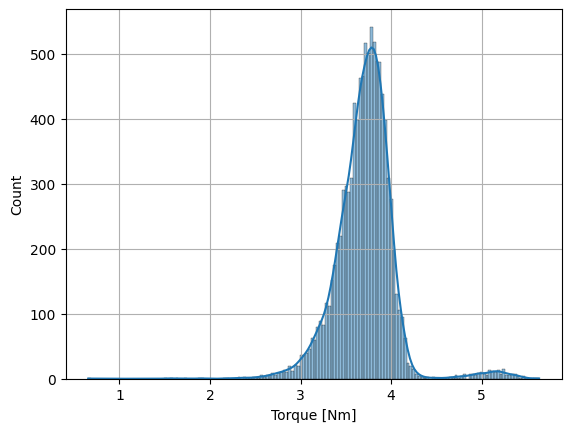

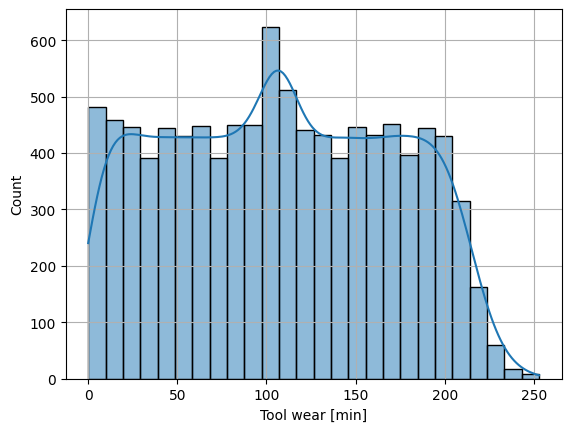

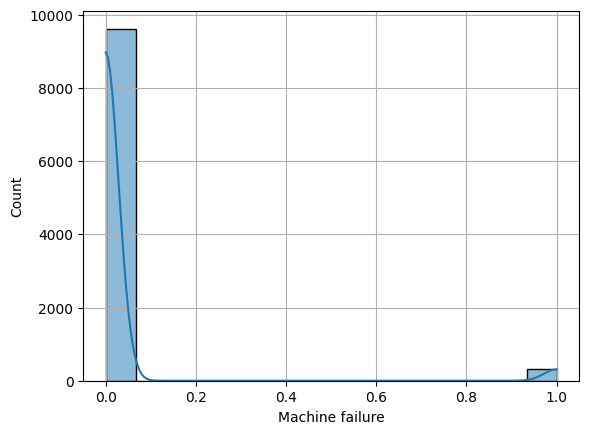

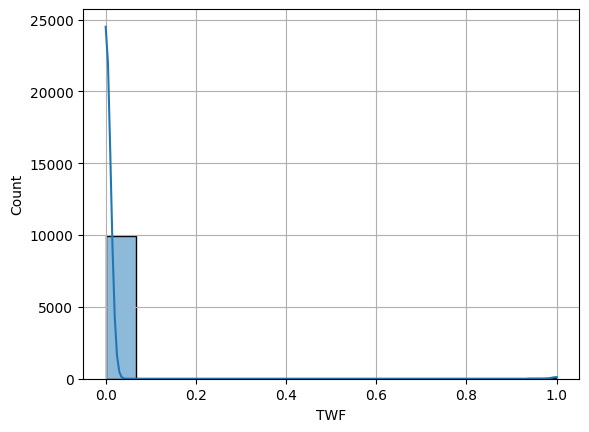

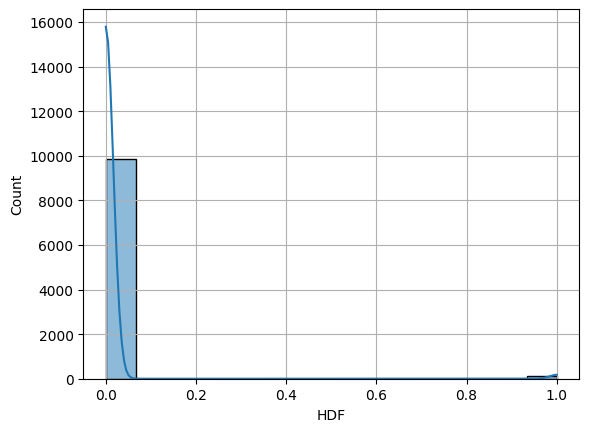

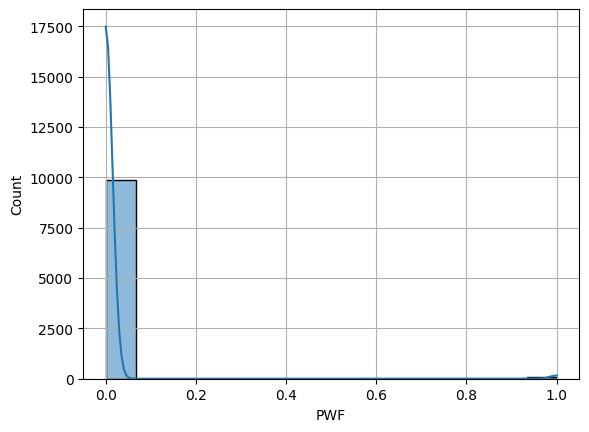

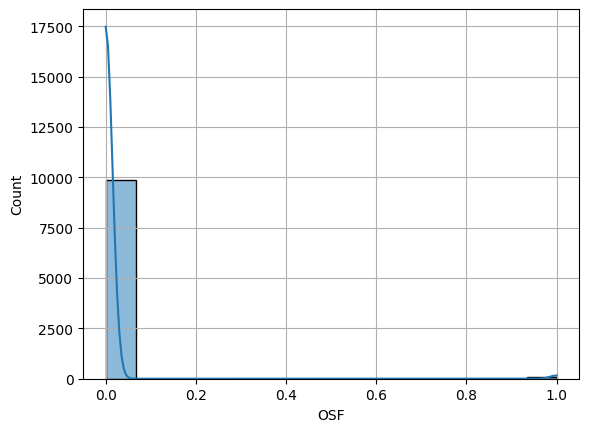

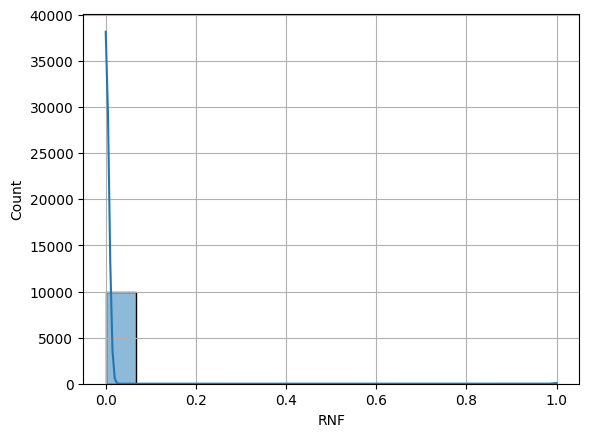

In [17]:
for col in numerical_col:
    sns.histplot(data[col], kde = True)
    plt.grid(True)
    plt.show()

In [18]:
data["Type"].unique()

array(['L', 'M', 'H', 'L_typo', 'M_typo', 'H_typo'], dtype=object)

In [19]:
data["Type"] = data["Type"].replace({"L_typo": "L", "M_typo": "M", "H_typo": "H"})
data["Type"].unique()

array(['L', 'M', 'H'], dtype=object)

In [20]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data["Type"] = labelencoder.fit_transform(data["Type"])

In [21]:
x = data.drop("Machine failure", axis = 1)
y = data["Machine failure"]

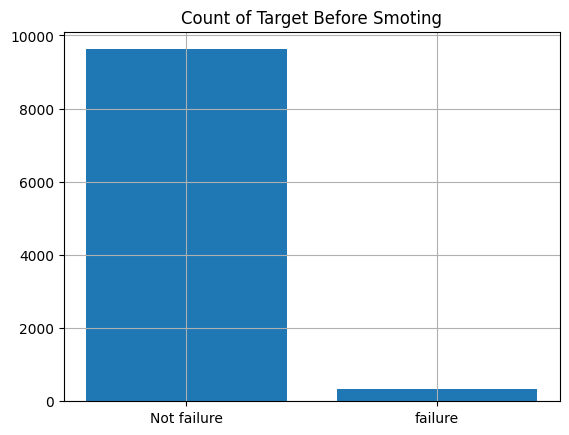

In [22]:
Target = y.value_counts()
plt.bar(Target.index, Target.values)
plt.xticks([0, 1], ["Not failure", "failure"])
plt.grid(True)
plt.title("Count of Target Before Smoting")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.80, random_state = 42, stratify = y)

---------

                                                          New Additions =>

In [24]:
from sklearn.impute import SimpleImputer

# Create an imputer and fit it ONLY on the training data
imputer = SimpleImputer(strategy="median")

x_train_imputed = pd.DataFrame(
    imputer.fit_transform(x_train),
    columns=x_train.columns,
    index=x_train.index
)

x_test_imputed = pd.DataFrame(
    imputer.transform(x_test),
    columns=x_test.columns,
    index=x_test.index
)

print("Missing values after imputation:")
print("X_train:", x_train_imputed.isna().sum().sum())
print("X_test :", x_test_imputed.isna().sum().sum())

print("\nTrain shape:", x_train_imputed.shape)
print("Test shape :", x_test_imputed.shape)

Missing values after imputation:
X_train: 0
X_test : 0

Train shape: (7964, 11)
Test shape : (1992, 11)


----------

# PHASE 5 — BASELINE MODEL =>

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    x_train_imputed,
    y_train
)

y_baseline_pred = baseline_model.predict(
    x_test_imputed
)

y_baseline_prob = baseline_model.predict_proba(
    x_test_imputed
)[:, 1]

baseline_accuracy = accuracy_score(
    y_test,
    y_baseline_pred
)

baseline_precision = precision_score(
    y_test,
    y_baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_baseline_pred,
    zero_division=0
)

baseline_roc_auc = roc_auc_score(
    y_test,
    y_baseline_prob
)

baseline_pr_auc = average_precision_score(
    y_test,
    y_baseline_prob
)

print("=" * 30)
print("   PHASE 5 — BASELINE MODEL")
print("=" * 30)

print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1-Score  : {baseline_f1:.4f}")
print(f"ROC-AUC   : {baseline_roc_auc:.4f}")
print(f"PR-AUC    : {baseline_pr_auc:.4f}")

   PHASE 5 — BASELINE MODEL
Accuracy  : 0.9664
Precision : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000
ROC-AUC   : 0.5000
PR-AUC    : 0.0336


                                                         LOGISTIC REGRESSION

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


logistic_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_baseline.fit(
    x_train_imputed,
    y_train
)

y_logistic_pred = logistic_baseline.predict(
    x_test_imputed
)

y_logistic_prob = logistic_baseline.predict_proba(
    x_test_imputed
)[:, 1]

logistic_accuracy = accuracy_score(
    y_test,
    y_logistic_pred
)

logistic_precision = precision_score(
    y_test,
    y_logistic_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_logistic_pred,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_logistic_pred,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_logistic_prob
)

logistic_pr_auc = average_precision_score(
    y_test,
    y_logistic_prob
)

print("=" * 50)
print("    PHASE 5.1 — LOGISTIC REGRESSION BASELINE")
print("=" * 50)

print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1-Score  : {logistic_f1:.4f}")
print(f"ROC-AUC   : {logistic_roc_auc:.4f}")
print(f"PR-AUC    : {logistic_pr_auc:.4f}")

    PHASE 5.1 — LOGISTIC REGRESSION BASELINE
Accuracy  : 0.9980
Precision : 1.0000
Recall    : 0.9403
F1-Score  : 0.9692
ROC-AUC   : 0.9841
PR-AUC    : 0.9563


                                                           MODEL COMPARISON

In [33]:
print("=" * 40)
print("       TARGET DISTRIBUTION CHECK")
print("=" * 40)

print("\nTraining set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTest set:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

       TARGET DISTRIBUTION CHECK

Training set:
Machine failure
0.0    7698
1.0     266
Name: count, dtype: int64
Machine failure
0.0    0.9666
1.0    0.0334
Name: proportion, dtype: float64

Test set:
Machine failure
0.0    1925
1.0      67
Name: count, dtype: int64
Machine failure
0.0    0.966365
1.0    0.033635
Name: proportion, dtype: float64


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

                                                          Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier


decision_tree = DecisionTreeClassifier(
    random_state=42
)

dt_result = evaluate_model(
    decision_tree,
    x_train_imputed,
    x_test_imputed,
    y_train,
    y_test,
    "Decision Tree"
)

print("=" * 30)
print("   PHASE 6.1 — DECISION TREE")
print("=" * 30)

for metric, value in dt_result.items():
    if metric != "Model":
        print(f"{metric:<12}: {value:.4f}")

   PHASE 6.1 — DECISION TREE
Accuracy    : 0.9965
Precision   : 0.9412
Recall      : 0.9552
F1-Score    : 0.9481
ROC-AUC     : 0.9766
PR-AUC      : 0.9005


                                                           RANDOM FOREST

In [38]:
from sklearn.ensemble import RandomForestClassifier


random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_result = evaluate_model(
    random_forest,
    x_train_imputed,
    x_test_imputed,
    y_train,
    y_test,
    "Random Forest"
)

print("=" * 30)
print("  PHASE 6.2 — RANDOM FOREST")
print("=" * 30)

for metric, value in rf_result.items():
    if metric != "Model":
        print(f"{metric:<12}: {value:.4f}")

  PHASE 6.2 — RANDOM FOREST
Accuracy    : 0.9980
Precision   : 1.0000
Recall      : 0.9403
F1-Score    : 0.9692
ROC-AUC     : 0.9908
PR-AUC      : 0.9773


                                                                     SVM

In [39]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

svm_result = evaluate_model(
    svm_model,
    x_train_imputed,
    x_test_imputed,
    y_train,
    y_test,
    "SVM"
)

print("=" * 15)
print("PHASE 6.3 — SVM")
print("=" * 15)

for metric, value in svm_result.items():
    if metric != "Model":
        print(f"{metric:<12}: {value:.4f}")

PHASE 6.3 — SVM
Accuracy    : 0.9980
Precision   : 1.0000
Recall      : 0.9403
F1-Score    : 0.9692
ROC-AUC     : 0.9841
PR-AUC      : 0.9583


                                                          MODEL COMPARISON TABLE

In [41]:
import pandas as pd


model_results = pd.DataFrame([
    {
        "Model": "Dummy Classifier",
        "Accuracy": baseline_accuracy,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "F1-Score": baseline_f1,
        "ROC-AUC": baseline_roc_auc,
        "PR-AUC": baseline_pr_auc
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1-Score": logistic_f1,
        "ROC-AUC": logistic_roc_auc,
        "PR-AUC": logistic_pr_auc
    },
    dt_result,
    rf_result,
    svm_result
])

model_results = model_results.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

print("=" * 40)
print("      PHASE 7 — MODEL COMPARISON")
print("=" * 40)

display(model_results.round(4))

      PHASE 7 — MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.9980,1.0000,0.9403,0.9692,0.9908,0.9773
1,SVM,0.9980,1.0000,0.9403,0.9692,0.9841,0.9583
2,Logistic Regression,0.9980,1.0000,0.9403,0.9692,0.9841,0.9563
3,Decision Tree,0.9965,0.9412,0.9552,0.9481,0.9766,0.9005
4,Dummy Classifier,0.9664,0.0000,0.0000,0.0000,0.5000,0.0336


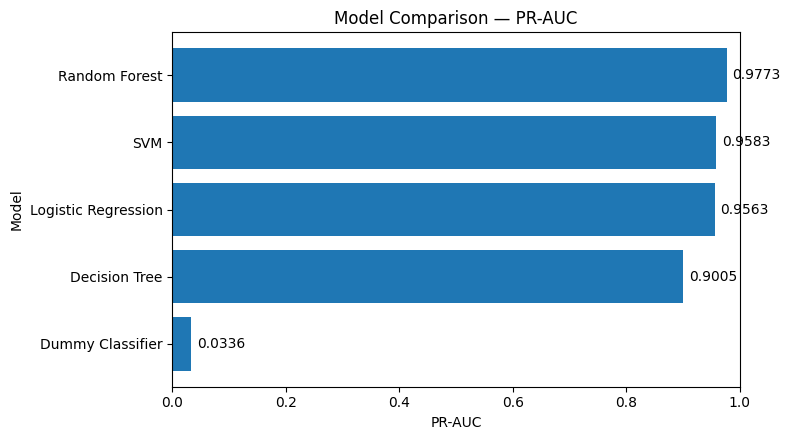

In [43]:
import matplotlib.pyplot as plt

plot_data = model_results.sort_values(
    by="PR-AUC",
    ascending=True
)

plt.figure(figsize=(8, 4.5))

plt.barh(
    plot_data["Model"],
    plot_data["PR-AUC"]
)

plt.xlabel("PR-AUC")
plt.ylabel("Model")
plt.title("Model Comparison — PR-AUC")

plt.xlim(0, 1)

# Add values on bars
for i, value in enumerate(plot_data["PR-AUC"]):
    plt.text(
        value + 0.01,
        i,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

###PHASE 8 => HYPERPARAMETER TUNING :

                                                        RANDOM FOREST TUNING

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_distributions = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 5, 8, 12, 16, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_distributions,
    n_iter=30,
    scoring="average_precision",
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_random_search.fit(
    x_train_imputed,
    y_train
)

print("=" * 40)
print("PHASE 8.1 — RANDOM FOREST TUNING")
print("=" * 40)

print("\nBest Parameters:")
print(rf_random_search.best_params_)

print(f"\nBest CV PR-AUC: {rf_random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
PHASE 8.1 — RANDOM FOREST TUNING

Best Parameters:
{'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': None}

Best CV PR-AUC: 0.9669


                                                       TUNED RANDOM FOREST EVALUATION

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# Best model from RandomizedSearchCV
best_rf = rf_random_search.best_estimator_

# Predictions
y_pred_tuned = best_rf.predict(x_test_imputed)

# Probability scores
y_prob_tuned = best_rf.predict_proba(x_test_imputed)[:, 1]

# Metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned, zero_division=0)
tuned_recall = recall_score(y_test, y_pred_tuned, zero_division=0)
tuned_f1 = f1_score(y_test, y_pred_tuned, zero_division=0)
tuned_roc_auc = roc_auc_score(y_test, y_prob_tuned)
tuned_pr_auc = average_precision_score(y_test, y_prob_tuned)

print("=" * 50)
print("           PHASE 8.2 — TUNED RANDOM FOREST")
print("=" * 50)

print(f"Accuracy  : {tuned_accuracy:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")
print(f"F1-Score  : {tuned_f1:.4f}")
print(f"ROC-AUC   : {tuned_roc_auc:.4f}")
print(f"PR-AUC    : {tuned_pr_auc:.4f}")

           PHASE 8.2 — TUNED RANDOM FOREST
Accuracy  : 0.9980
Precision : 1.0000
Recall    : 0.9403
F1-Score  : 0.9692
ROC-AUC   : 0.9871
PR-AUC    : 0.9727


                                                       Generate OOF Probabilities

In [47]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone


# Use the baseline Random Forest (current champion)
rf_champion = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

cv_threshold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold probability predictions
y_train_prob_oof = cross_val_predict(
    rf_champion,
    x_train_imputed,
    y_train,
    cv=cv_threshold,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("=" * 30)
print("PHASE 9.1 — OOF PROBABILITIES")
print("=" * 30)

print(f"Training samples : {len(y_train)}")
print(f"OOF probabilities: {len(y_train_prob_oof)}")
print(f"Positive samples : {y_train.sum()}")

PHASE 9.1 — OOF PROBABILITIES
Training samples : 7964
OOF probabilities: 7964
Positive samples : 266.0


                                                          Threshold Analysis

In [48]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)


thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    # Convert probabilities to class predictions
    y_pred_threshold = (
        y_train_prob_oof >= threshold
    ).astype(int)

    # Calculate metrics
    precision = precision_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_results = pd.DataFrame(threshold_results)

print("=" * 30)
print("PHASE 9.2 — THRESHOLD ANALYSIS")
print("=" * 30)

display(
    threshold_results.round(4)
)

PHASE 9.2 — THRESHOLD ANALYSIS


,Threshold,Precision,Recall,F1-Score
0,0.10,0.9097,0.9474,0.9282
1,0.15,0.9508,0.9436,0.9472
2,0.20,0.9843,0.9436,0.9635
3,0.25,0.9960,0.9436,0.9691
4,0.30,0.9960,0.9436,0.9691
5,0.35,1.0000,0.9436,0.9710
6,0.40,1.0000,0.9436,0.9710
7,0.45,1.0000,0.9436,0.9710
8,0.50,1.0000,0.9436,0.9710
9,0.55,1.0000,0.9436,0.9710


In [49]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1-Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("=" * 15)
print("BEST THRESHOLD")
print("=" * 15)

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Precision      : {best_threshold_row['Precision']:.4f}")
print(f"Recall         : {best_threshold_row['Recall']:.4f}")
print(f"F1-Score       : {best_threshold_row['F1-Score']:.4f}")

BEST THRESHOLD
Best Threshold : 0.35
Precision      : 1.0000
Recall         : 0.9436
F1-Score       : 0.9710


                                                       THRESHOLD TEST EVALUATION

In [50]:
# Use the original baseline Random Forest
# (our current champion model)
rf_champion.fit(
    x_train_imputed,
    y_train
)

# Test probabilities
y_test_prob = rf_champion.predict_proba(
    x_test_imputed
)[:, 1]

# Default threshold = 0.50
y_pred_050 = (
    y_test_prob >= 0.50
).astype(int)

# Optimized threshold = 0.35
y_pred_035 = (
    y_test_prob >= best_threshold
).astype(int)

# =========================
# Metrics — Threshold 0.50
# =========================

precision_050 = precision_score(
    y_test,
    y_pred_050,
    zero_division=0
)

recall_050 = recall_score(
    y_test,
    y_pred_050,
    zero_division=0
)

f1_050 = f1_score(
    y_test,
    y_pred_050,
    zero_division=0
)

# =========================
# Metrics — Threshold 0.35
# =========================

precision_035 = precision_score(
    y_test,
    y_pred_035,
    zero_division=0
)

recall_035 = recall_score(
    y_test,
    y_pred_035,
    zero_division=0
)

f1_035 = f1_score(
    y_test,
    y_pred_035,
    zero_division=0
)

# ===================
# Display Comparison
# ===================

print("=" * 55)
print("PHASE 9.4 — TEST SET THRESHOLD COMPARISON")
print("=" * 55)

print("\nThreshold = 0.50")
print(f"Precision : {precision_050:.4f}")
print(f"Recall    : {recall_050:.4f}")
print(f"F1-Score  : {f1_050:.4f}")

print("\nThreshold = 0.35")
print(f"Precision : {precision_035:.4f}")
print(f"Recall    : {recall_035:.4f}")
print(f"F1-Score  : {f1_035:.4f}")

PHASE 9.4 — TEST SET THRESHOLD COMPARISON

Threshold = 0.50
Precision : 1.0000
Recall    : 0.9403
F1-Score  : 0.9692

Threshold = 0.35
Precision : 1.0000
Recall    : 0.9403
F1-Score  : 0.9692


-----------

    PHASE 10.1 — CONFUSION MATRIX
True Negatives  : 1925
False Positives : 0
False Negatives : 4
True Positives  : 63

Failure Detection:
Actual Failures     : 67
Detected Failures   : 63
Missed Failures     : 4


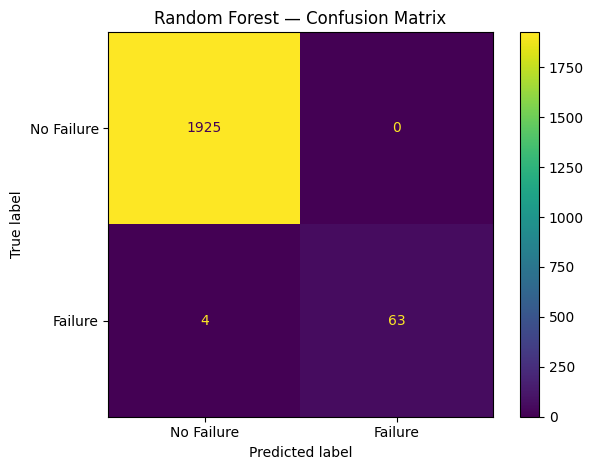

In [52]:
# PHASE 10.1 — CONFUSION MATRIX & ERROR ANALYSIS

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_050)

tn, fp, fn, tp = cm.ravel()

print("=" * 40)
print("    PHASE 10.1 — CONFUSION MATRIX")
print("=" * 40)
print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")

print("\nFailure Detection:")
print(f"Actual Failures     : {tp + fn}")
print(f"Detected Failures   : {tp}")
print(f"Missed Failures     : {fn}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)

disp.plot()
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

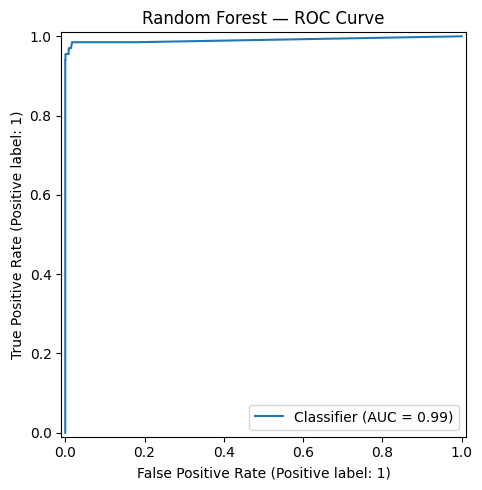

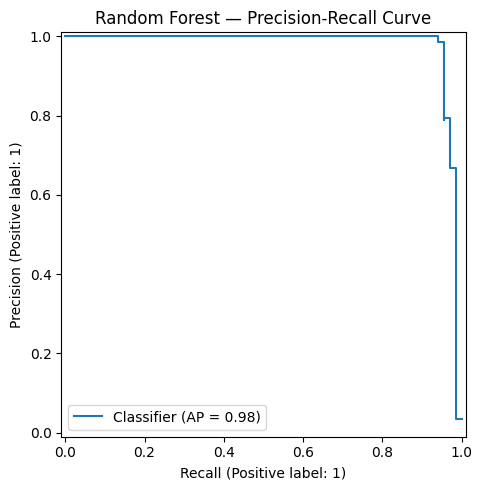

In [53]:
# PHASE 10.2 — ROC & PRECISION-RECALL CURVES

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=ax)
ax.set_title("Random Forest — ROC Curve")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_test_prob, ax=ax)
ax.set_title("Random Forest — Precision-Recall Curve")
plt.tight_layout()
plt.show()

In [55]:
# PHASE 10.3 — FINAL MODEL COMPARISON

final_results = model_results.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("PHASE 10.3 — FINAL MODEL COMPARISON")
print("=" * 70)

display(final_results.round(4))

print(f"\n Champion Model: {final_results.iloc[0]['Model']}")
print(f" Best PR-AUC   : {final_results.iloc[0]['PR-AUC']:.4f}")

PHASE 10.3 — FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.9980,1.0000,0.9403,0.9692,0.9908,0.9773
1,SVM,0.9980,1.0000,0.9403,0.9692,0.9841,0.9583
2,Logistic Regression,0.9980,1.0000,0.9403,0.9692,0.9841,0.9563
3,Decision Tree,0.9965,0.9412,0.9552,0.9481,0.9766,0.9005
4,Dummy Classifier,0.9664,0.0000,0.0000,0.0000,0.5000,0.0336



 Champion Model: Random Forest
 Best PR-AUC   : 0.9773


In [57]:
# PHASE 11 — SAVE FINAL MODEL

import joblib

final_model = rf_champion

joblib.dump(
    final_model,
    "machine_failure_random_forest.pkl"
)

print("=" * 30)
print("PHASE 11 — FINAL MODEL SAVED")
print("=" * 30)
print("Model: Random Forest")
print("PR-AUC: 0.9773")
print("File: machine_failure_random_forest.pkl")

PHASE 11 — FINAL MODEL SAVED
Model: Random Forest
PR-AUC: 0.9773
File: machine_failure_random_forest.pkl


In [58]:
# PHASE 12 — FINAL PROJECT SUMMARY

print("=" * 75)
print("FINAL PROJECT SUMMARY — MACHINE FAILURE PREDICTION")
print("=" * 75)

print("\nDataset:")
print(f"Training samples : {len(y_train)}")
print(f"Testing samples  : {len(y_test)}")
print(f"Features         : {x_train_imputed.shape[1]}")
print(f"Positive class   : {y_train.sum():.0f} train / {y_test.sum():.0f} test")

print("\nModel Comparison:")
print(f"Champion Model   : Random Forest")
print(f"Accuracy         : 0.9980")
print(f"Precision        : 1.0000")
print(f"Recall           : 0.9403")
print(f"F1-Score         : 0.9692")
print(f"ROC-AUC          : 0.9908")
print(f"PR-AUC           : 0.9773")

print("\nTuning:")
print(f"Tuned RF PR-AUC  : 0.9727")
print("Result           : Baseline RF retained")

print("\nThreshold:")
print(f"OOF Best         : {best_threshold:.2f}")
print("Test Result      : No improvement over threshold 0.50")

print("\nSaved Model:")
print("machine_failure_random_forest.pkl")

print("\n" + "=" * 75)
print("FINAL MODEL: RANDOM FOREST")
print("STATUS: MODELING PIPELINE COMPLETED")
print("=" * 75)

FINAL PROJECT SUMMARY — MACHINE FAILURE PREDICTION

Dataset:
Training samples : 7964
Testing samples  : 1992
Features         : 11
Positive class   : 266 train / 67 test

Model Comparison:
Champion Model   : Random Forest
Accuracy         : 0.9980
Precision        : 1.0000
Recall           : 0.9403
F1-Score         : 0.9692
ROC-AUC          : 0.9908
PR-AUC           : 0.9773

Tuning:
Tuned RF PR-AUC  : 0.9727
Result           : Baseline RF retained

Threshold:
OOF Best         : 0.35
Test Result      : No improvement over threshold 0.50

Saved Model:
machine_failure_random_forest.pkl

FINAL MODEL: RANDOM FOREST
STATUS: MODELING PIPELINE COMPLETED


----------

In [59]:
# PHASE 13 — DASHBOARD IMPORTS

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

In [61]:
# PHASE 13.1 — INTERACTIVE ML DASHBOARD

import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2,
    cols=3,
    specs=[
        [{"type": "domain"}, {"type": "bar"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "bar"}, {"type": "domain"}]
    ],
    subplot_titles=(
        "Machine Failure Distribution",
        "Model PR-AUC",
        "Model Accuracy",
        "Model F1-Score",
        "Model Recall",
        "Champion Model"
    ),
    vertical_spacing=0.16,
    horizontal_spacing=0.08
)

# Dataset distribution
failure_counts = pd.Series(y_test).value_counts().sort_index()

fig.add_trace(
    go.Pie(
        labels=["No Failure", "Failure"],
        values=[
            failure_counts.get(0, 0),
            failure_counts.get(1, 0)
        ],
        hole=0.55,
        textinfo="label+percent"
    ),
    row=1,
    col=1
)

# PR-AUC
model_plot = final_results.iloc[::-1]

fig.add_trace(
    go.Bar(
        x=model_plot["PR-AUC"],
        y=model_plot["Model"],
        orientation="h",
        text=model_plot["PR-AUC"].round(4),
        textposition="outside"
    ),
    row=1,
    col=2
)

# Accuracy
fig.add_trace(
    go.Bar(
        x=model_plot["Accuracy"],
        y=model_plot["Model"],
        orientation="h",
        text=model_plot["Accuracy"].round(4),
        textposition="outside"
    ),
    row=1,
    col=3
)

# F1
fig.add_trace(
    go.Bar(
        x=model_plot["F1-Score"],
        y=model_plot["Model"],
        orientation="h",
        text=model_plot["F1-Score"].round(4),
        textposition="outside"
    ),
    row=2,
    col=1
)

# Recall
fig.add_trace(
    go.Bar(
        x=model_plot["Recall"],
        y=model_plot["Model"],
        orientation="h",
        text=model_plot["Recall"].round(4),
        textposition="outside"
    ),
    row=2,
    col=2
)

# Champion
fig.add_trace(
    go.Pie(
        labels=["PR-AUC"],
        values=[0.9773],
        hole=0.65,
        textinfo="none"
    ),
    row=2,
    col=3
)

fig.update_layout(
    title={
        "text": " MACHINE FAILURE PREDICTION — ML DASHBOARD",
        "x": 0.5,
        "xanchor": "center"
    },
    height=850,
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(range=[0, 1], row=1, col=2)
fig.update_xaxes(range=[0, 1], row=1, col=3)
fig.update_xaxes(range=[0, 1], row=2, col=1)
fig.update_xaxes(range=[0, 1], row=2, col=2)

fig.show()

In [62]:
# PHASE 13.2 — EXPORT DASHBOARD

fig.write_html("machine_failure_dashboard.html")

print("Dashboard exported successfully!")
print("File: machine_failure_dashboard.html")

Dashboard exported successfully!
File: machine_failure_dashboard.html


------------

In [63]:
# PHASE 14 — PREPARE PROJECT ARTIFACTS

import os
import shutil

os.makedirs("machine_failure_project", exist_ok=True)

files_to_copy = [
    "machine_failure_random_forest.pkl",
    "machine_failure_dashboard.html"
]

for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, "machine_failure_project")

print("Project artifacts prepared successfully!")
print(os.listdir("machine_failure_project"))

Project artifacts prepared successfully!
['machine_failure_dashboard.html', 'machine_failure_random_forest.pkl']


In [64]:
# PHASE 15 — FINAL PROJECT REPORT

print("=" * 40)
print("MACHINE FAILURE PREDICTION — FINAL REPORT")
print("=" * 40)

print(f"\nDataset")
print(f"Training Samples : {len(y_train)}")
print(f"Testing Samples  : {len(y_test)}")
print(f"Features         : {x_train_imputed.shape[1]}")

print(f"\nChampion Model")
print(f"Model     : Random Forest")
print(f"Accuracy  : 0.9980")
print(f"Precision : 1.0000")
print(f"Recall    : 0.9403")
print(f"F1-Score  : 0.9692")
print(f"ROC-AUC   : 0.9908")
print(f"PR-AUC    : 0.9773")

print(f"\nSaved Artifacts")
print("✓ machine_failure_random_forest.pkl")
print("✓ machine_failure_dashboard.html")

print("\nSTATUS: PROJECT READY FOR KAGGLE & GITHUB ")
print("=" * 60)

MACHINE FAILURE PREDICTION — FINAL REPORT

Dataset
Training Samples : 7964
Testing Samples  : 1992
Features         : 11

Champion Model
Model     : Random Forest
Accuracy  : 0.9980
Precision : 1.0000
Recall    : 0.9403
F1-Score  : 0.9692
ROC-AUC   : 0.9908
PR-AUC    : 0.9773

Saved Artifacts
✓ machine_failure_random_forest.pkl
✓ machine_failure_dashboard.html

STATUS: PROJECT READY FOR KAGGLE & GITHUB 


-----------

##GitHub